# Machine Learning for Time Series Forecasting

## Datasets and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

# ── Load energy data ───────────────────────────────────────────────────────
energy_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/00374/energydata_complete.csv"
)
df_energy = pd.read_csv(energy_url, parse_dates=["date"])
df_energy = df_energy.set_index("date").sort_index()

print(f"Loaded energy dataset: {df_energy.shape[0]:,} rows, {df_energy.shape[1]} columns")
print(f"Period: {df_energy.index[0]} – {df_energy.index[-1]}")

Loaded energy dataset: 19,735 rows, 28 columns
Period: 2016-01-11 17:00:00 – 2016-05-27 18:00:00


## Feature Engineering on Energy Data

### Building the Feature Matrix

In [2]:
# ── Work with hourly energy data ───────────────────────────────────────────
df_ml = df_energy.copy().resample("1h").mean()
target_col = "Appliances"

# ── Lag features (1h to 48h) ──────────────────────────────────────────────
LAG_HOURS  = list(range(1, 25)) + [48]    # 1–24h + 48h
WIN_SIZES  = [6, 12, 24]

for lag in LAG_HOURS:
    df_ml[f"lag_{lag}h"] = df_ml[target_col].shift(lag)

# ── Rolling statistics (computed on lagged values to avoid leakage) ───────
for w in WIN_SIZES:
    df_ml[f"roll_mean_{w}h"] = df_ml[target_col].shift(1).rolling(w).mean()
    df_ml[f"roll_std_{w}h"]  = df_ml[target_col].shift(1).rolling(w).std()
    df_ml[f"roll_max_{w}h"]  = df_ml[target_col].shift(1).rolling(w).max()

# ── Calendar features ─────────────────────────────────────────────────────
df_ml["hour"]        = df_ml.index.hour
df_ml["dayofweek"]   = df_ml.index.dayofweek        # 0=Mon, 6=Sun
df_ml["month"]       = df_ml.index.month
df_ml["is_weekend"]  = (df_ml.index.dayofweek >= 5).astype(int)

# Cyclic encoding (hour and day of week)
df_ml["hour_sin"]    = np.sin(2 * np.pi * df_ml["hour"] / 24)
df_ml["hour_cos"]    = np.cos(2 * np.pi * df_ml["hour"] / 24)
df_ml["dow_sin"]     = np.sin(2 * np.pi * df_ml["dayofweek"] / 7)
df_ml["dow_cos"]     = np.cos(2 * np.pi * df_ml["dayofweek"] / 7)

# ── Drop NaN rows introduced by lags and rolling windows ─────────────────
df_ml = df_ml.dropna()

feature_cols = [c for c in df_ml.columns if c != target_col]
X = df_ml[feature_cols]
y = df_ml[target_col]

print(f"Feature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Features             : {len(feature_cols)}")
print(f"  Lag features       : {len(LAG_HOURS)}")
print(f"  Rolling features   : {len(WIN_SIZES) * 3}")
print(f"  Calendar features  : {len(feature_cols) - len(LAG_HOURS) - len(WIN_SIZES)*3}")

Feature matrix shape : (3242, 69)
Target shape         : (3242,)
Features             : 69
  Lag features       : 25
  Rolling features   : 9
  Calendar features  : 35


## Walk-Forward Cross-Validation

Training set : 2,522 observations (2016-01-13 – 2016-04-27)
Test set     : 720 observations (2016-04-27 – 2016-05-27)


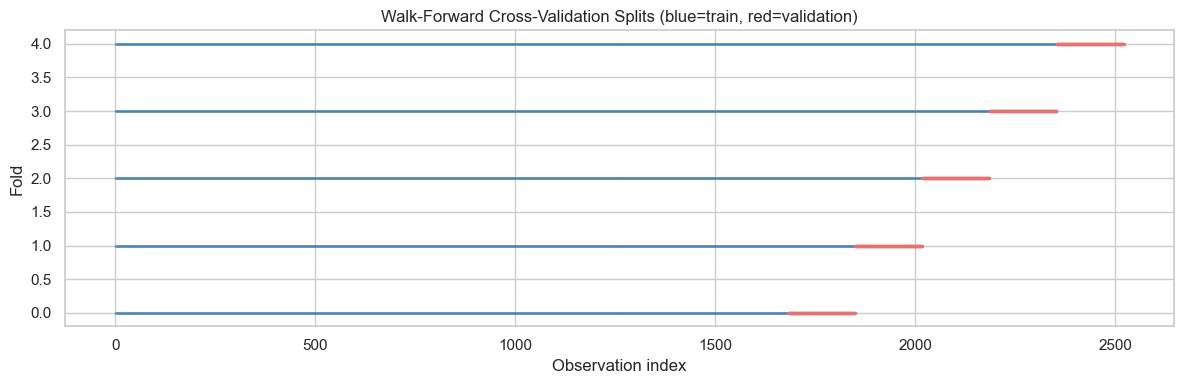

In [3]:
from sklearn.model_selection import TimeSeriesSplit

# ── Time-series-safe train/test split ─────────────────────────────────────
# Hold out final 30 days (720 hours) for final evaluation
HOLDOUT_ML = 24 * 30

X_train_ml = X.iloc[:-HOLDOUT_ML]
y_train_ml = y.iloc[:-HOLDOUT_ML]
X_test_ml  = X.iloc[-HOLDOUT_ML:]
y_test_ml  = y.iloc[-HOLDOUT_ML:]

print(f"Training set : {len(X_train_ml):,} observations "
      f"({X_train_ml.index[0].date()} – {X_train_ml.index[-1].date()})")
print(f"Test set     : {len(X_test_ml):,} observations "
      f"({X_test_ml.index[0].date()} – {X_test_ml.index[-1].date()})")

# ── Walk-forward CV with 5 folds for model selection ──────────────────────
tscv = TimeSeriesSplit(n_splits=5, test_size=24 * 7)   # 1-week test folds

# Visualise the CV splits
fig, ax = plt.subplots(figsize=(12, 4))
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_ml)):
    ax.scatter(tr_idx,  [fold] * len(tr_idx),  c="steelblue", s=1, alpha=0.3)
    ax.scatter(val_idx, [fold] * len(val_idx),  c="#E57373",   s=2)
ax.set_xlabel("Observation index")
ax.set_ylabel("Fold")
ax.set_title("Walk-Forward Cross-Validation Splits (blue=train, red=validation)")
plt.tight_layout()
plt.savefig(FIGURES / "ch04_wf_cv.png", dpi=150, bbox_inches="tight")
plt.show()

## Gradient Boosting Forecaster

### Training and Evaluation

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

# ── LightGBM — fast gradient boosting well-suited to tabular time series ──
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)

# ── Walk-forward CV to estimate generalisation error ──────────────────────
cv_maes, cv_rmses, cv_mapes = [], [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_ml)):
    X_tr  = X_train_ml.iloc[tr_idx]
    y_tr  = y_train_ml.iloc[tr_idx]
    X_val = X_train_ml.iloc[val_idx]
    y_val = y_train_ml.iloc[val_idx]

    lgb_model.fit(X_tr, y_tr)
    preds = lgb_model.predict(X_val)

    cv_maes.append(mean_absolute_error(y_val, preds))
    cv_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))
    cv_mapes.append(np.mean(np.abs((y_val.values - preds) / y_val.values)) * 100)

print(f"LightGBM Walk-Forward CV (5 folds):")
print(f"  MAE  : {np.mean(cv_maes):.2f} ± {np.std(cv_maes):.2f} Wh")
print(f"  RMSE : {np.mean(cv_rmses):.2f} ± {np.std(cv_rmses):.2f} Wh")
print(f"  MAPE : {np.mean(cv_mapes):.2f}% ± {np.std(cv_mapes):.2f}%")

# ── Final model — retrain on full training set, evaluate on holdout ───────
lgb_model.fit(X_train_ml, y_train_ml)
lgb_preds = lgb_model.predict(X_test_ml)

mae_lgb  = mean_absolute_error(y_test_ml, lgb_preds)
rmse_lgb = np.sqrt(mean_squared_error(y_test_ml, lgb_preds))
mape_lgb = np.mean(np.abs((y_test_ml.values - lgb_preds) / y_test_ml.values)) * 100

print(f"\nLightGBM — Holdout test (30 days):")
print(f"  MAE  : {mae_lgb:.2f} Wh")
print(f"  RMSE : {rmse_lgb:.2f} Wh")
print(f"  MAPE : {mape_lgb:.2f}%")

LightGBM Walk-Forward CV (5 folds):
  MAE  : 36.31 ± 3.96 Wh
  RMSE : 59.51 ± 7.59 Wh
  MAPE : 36.03% ± 4.17%

LightGBM — Holdout test (30 days):
  MAE  : 41.06 Wh
  RMSE : 58.50 Wh
  MAPE : 46.35%


### Feature Importance

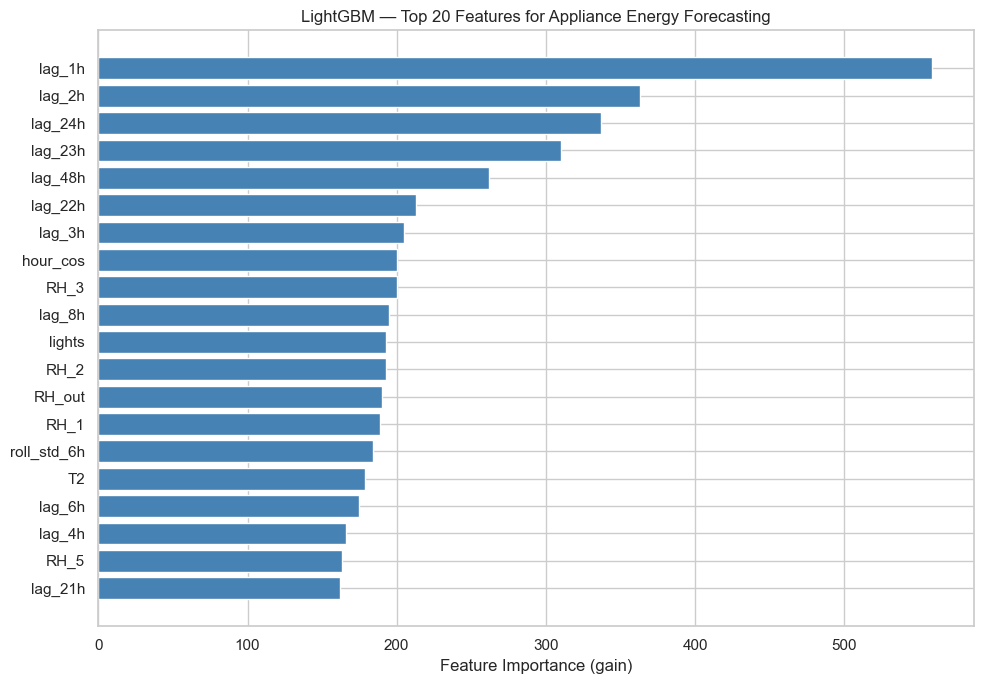

Top 10 features:
 feature  importance
  lag_1h         559
  lag_2h         363
 lag_24h         337
 lag_23h         310
 lag_48h         262
 lag_22h         213
  lag_3h         205
hour_cos         200
    RH_3         200
  lag_8h         195


In [5]:
# ── Feature importance ────────────────────────────────────────────────────
importance_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(importance_df["feature"][::-1], importance_df["importance"][::-1],
        color="steelblue", edgecolor="white")
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("LightGBM — Top 20 Features for Appliance Energy Forecasting")
plt.tight_layout()
plt.savefig(FIGURES / "ch04_lgb_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 features:")
print(importance_df.head(10).to_string(index=False))

## LSTM Forecaster

### Data Preparation and Architecture

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler as MMS

SEQ_LEN  = 48    # 48-hour look-back window
HORIZON  = 1     # 1-step-ahead forecast

# Scale target only (keep it simple for a clean comparison)
scaler_lstm = MMS()
y_scaled = scaler_lstm.fit_transform(y.values.reshape(-1, 1)).flatten()

def make_sequences(arr, seq_len, horizon):
    X_seq, y_seq = [], []
    for i in range(len(arr) - seq_len - horizon + 1):
        X_seq.append(arr[i : i + seq_len])
        y_seq.append(arr[i + seq_len + horizon - 1])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

X_seq, y_seq = make_sequences(y_scaled, SEQ_LEN, HORIZON)

# Train/test split preserving order
split = len(X_seq) - HOLDOUT_ML
X_seq_train, X_seq_test = X_seq[:split], X_seq[split:]
y_seq_train, y_seq_test = y_seq[:split], y_seq[split:]

train_ds = TensorDataset(torch.tensor(X_seq_train).unsqueeze(-1),
                         torch.tensor(y_seq_train))
test_ds  = TensorDataset(torch.tensor(X_seq_test).unsqueeze(-1),
                         torch.tensor(y_seq_test))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,
                          generator=torch.Generator().manual_seed(RANDOM_SEED))

# ── LSTM architecture ─────────────────────────────────────────────────────
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

torch.manual_seed(RANDOM_SEED)
lstm_model = LSTMForecaster()
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion  = nn.MSELoss()

print(lstm_model)
print(f"\nTrainable parameters: "
      f"{sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")

LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 50,497


### Training Loop

In [7]:
# ── Training loop ─────────────────────────────────────────────────────────
N_EPOCHS = 30
train_losses = []

lstm_model.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        pred = lstm_model(X_b)
        loss = criterion(pred, y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item() * len(y_b)
    train_losses.append(epoch_loss / len(train_ds))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:>3} / {N_EPOCHS}  —  Train MSE: {train_losses[-1]:.6f}")

# ── Evaluate on test set ───────────────────────────────────────────────────
lstm_model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_seq_test).unsqueeze(-1)
    lstm_preds_scaled = lstm_model(X_test_t).numpy()

lstm_preds = scaler_lstm.inverse_transform(
    lstm_preds_scaled.reshape(-1, 1)).flatten()
y_test_lstm = scaler_lstm.inverse_transform(
    y_seq_test.reshape(-1, 1)).flatten()

# Align LightGBM predictions to same length as LSTM for fair comparison
lgb_preds_trimmed = lgb_preds[-len(lstm_preds):]
y_test_trimmed    = y_test_ml.values[-len(lstm_preds):]

mae_lstm  = mean_absolute_error(y_test_lstm, lstm_preds)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, lstm_preds))
mape_lstm = np.mean(np.abs((y_test_lstm - lstm_preds) / y_test_lstm)) * 100

print(f"\nLSTM — Holdout test (30 days):")
print(f"  MAE  : {mae_lstm:.2f} Wh")
print(f"  RMSE : {rmse_lstm:.2f} Wh")
print(f"  MAPE : {mape_lstm:.2f}%")

Epoch  10 / 30  —  Train MSE: 0.013275
Epoch  20 / 30  —  Train MSE: 0.012205
Epoch  30 / 30  —  Train MSE: 0.011400

LSTM — Holdout test (30 days):
  MAE  : 32.41 Wh
  RMSE : 53.66 Wh
  MAPE : 31.99%


### Forecast Visualisation

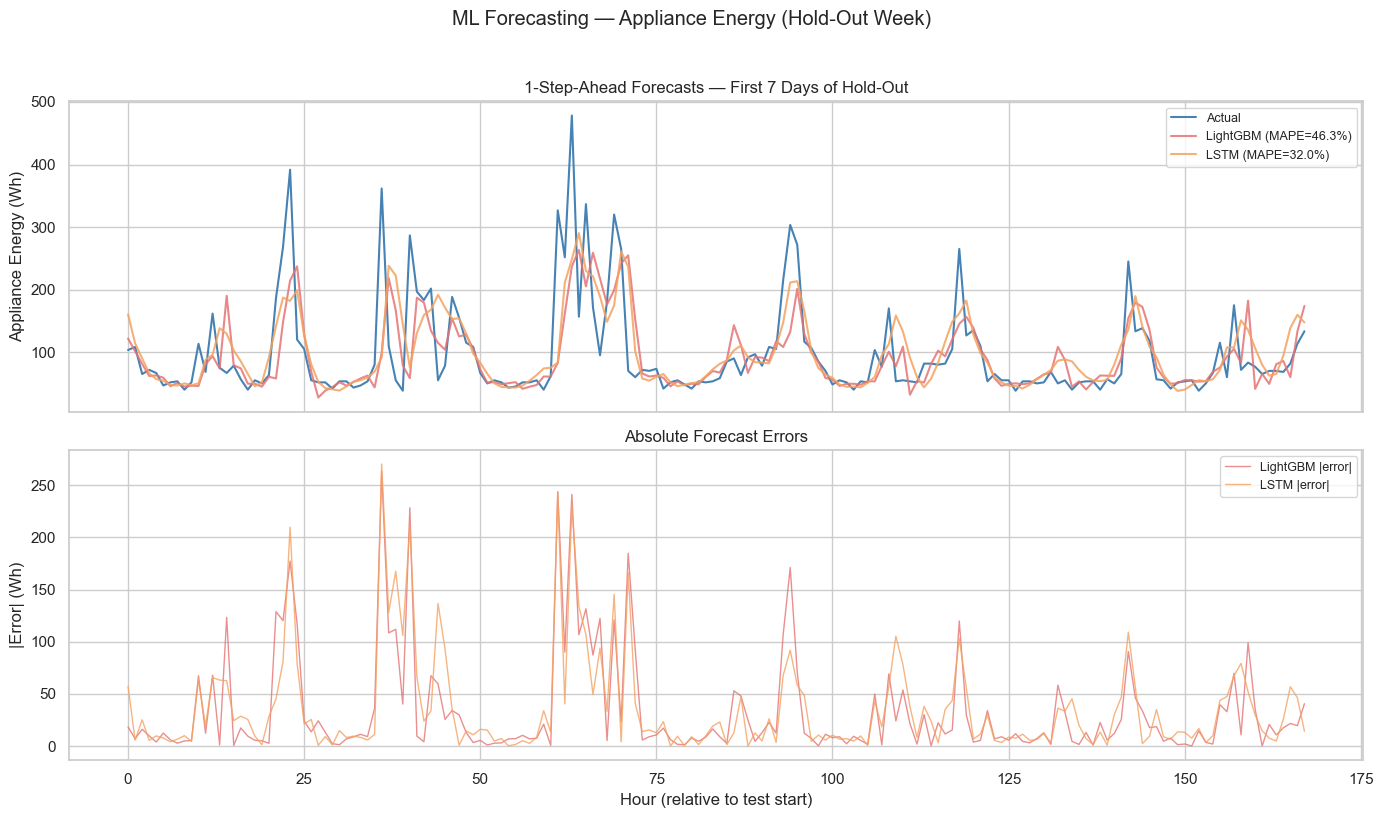

In [8]:
# ── Visual forecast comparison ─────────────────────────────────────────────
PLOT_DAYS = 7    # show one representative week
n_plot    = 24 * PLOT_DAYS

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x_axis = np.arange(n_plot)
axes[0].plot(x_axis, y_test_trimmed[:n_plot],  color="steelblue", lw=1.5, label="Actual")
axes[0].plot(x_axis, lgb_preds_trimmed[:n_plot], color="#E57373",  lw=1.5,
             label=f"LightGBM (MAPE={mape_lgb:.1f}%)", alpha=0.85)
axes[0].plot(x_axis, lstm_preds[:n_plot],        color="#F4A261",  lw=1.5,
             label=f"LSTM (MAPE={mape_lstm:.1f}%)", alpha=0.85)
axes[0].set_title("1-Step-Ahead Forecasts — First 7 Days of Hold-Out")
axes[0].set_ylabel("Appliance Energy (Wh)")
axes[0].legend(fontsize=9)

# Error comparison
lgb_errors  = np.abs(y_test_trimmed - lgb_preds_trimmed)
lstm_errors = np.abs(y_test_lstm - lstm_preds)

axes[1].plot(x_axis, lgb_errors[:n_plot],  color="#E57373", lw=1, alpha=0.8,
             label="LightGBM |error|")
axes[1].plot(x_axis, lstm_errors[:n_plot], color="#F4A261", lw=1, alpha=0.8,
             label="LSTM |error|")
axes[1].set_title("Absolute Forecast Errors")
axes[1].set_xlabel("Hour (relative to test start)")
axes[1].set_ylabel("|Error| (Wh)")
axes[1].legend(fontsize=9)

plt.suptitle("ML Forecasting — Appliance Energy (Hold-Out Week)", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch04_ml_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

## Evaluation and Method Comparison

### Final Comparison Table

In [9]:
# ── Summary comparison table ───────────────────────────────────────────────
print("=" * 65)
print(f"{'Model':<35}  {'MAE':>8}  {'RMSE':>8}  {'MAPE':>7}")
print("=" * 65)
print("─── Appliance Energy (30-day horizon, 1h ahead) ────────────────")
for name, mae_v, rmse_v, mape_v in [
    ("LightGBM",   mae_lgb,   rmse_lgb,  mape_lgb),
    ("LSTM",       mae_lstm,  rmse_lstm, mape_lstm),
]:
    print(f"  {name:<33}  {mae_v:>8.2f}  {rmse_v:>8.2f}  {mape_v:>6.2f}%")
print("=" * 65)

Model                                     MAE      RMSE     MAPE
─── Appliance Energy (30-day horizon, 1h ahead) ────────────────
  LightGBM                              41.06     58.50   46.35%
  LSTM                                  32.41     53.66   31.99%
